In [46]:
import os
import pandas as pd
import numpy as np
import pickle
import yaml

import warnings

from statsmodels.tsa.api import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from sklearn.model_selection import train_test_split
from pydlm import dlm, dynamic


In [47]:
warnings.filterwarnings("ignore")

In [48]:
df = pd.read_csv("../../data/pre_data.csv")
df["Ngày"] = pd.to_datetime(df["Ngày"], format="%Y-%m-%d")

In [49]:
df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá
0,OM 5451,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,6000.0
1,Đài Thơm 8,Sóc Trăng,Thương lái thu mua,CTV địa phương,2025-05-19,7125.0
2,OM 5451,Sóc Trăng,Thương lái thu mua,CTV địa phương,2025-05-19,7125.0
3,OM 5451,Kiên Giang,Thương lái thu mua,CTV địa phương,2025-05-16,5900.0
4,OM 5451,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-15,6000.0


In [50]:
df[df["Tên_mặt_hàng"] == "Gạo NL 25% tấm"]

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá


In [51]:
for col in ["Thị_trường", "Loại_giá", "Nguồn"]:
    lbl_encoder = LabelEncoder()
    df[col] = lbl_encoder.fit_transform(df[col])
    print(lbl_encoder.classes_)

    with open(f"../train/lbl_scaler/{col}.pkl", "wb") as file:
        pickle.dump(lbl_encoder, file)

['An Giang' 'Bạc Liêu' 'Bến Tre' 'Cà Mau' 'Cần Thơ' 'Hà Nội' 'Hậu Giang'
 'Kiên Giang' 'Long An' 'Sóc Trăng' 'Sơn La' 'Thái Bình' 'Tiền Giang'
 'Trà Vinh' 'Vĩnh Long' 'Đồng Tháp']
['Bán buôn' 'Bán lẻ' 'Khác' 'Thu mua' 'Thu mua tại vườn'
 'Thương lái thu mua' 'Tại chợ' 'Vựa thu mua' 'Đại lý thu mua']
['Bán lẻ' 'CTV địa phương' 'Cờ Đỏ' 'Giồng Riềng' 'Long Xuyên'
 'Tỉnh An Giang' 'huyện Quỳnh Phụ']


In [52]:
for col in ["Thị_trường", "Loại_giá", "Nguồn"]:
    scaler = MinMaxScaler()  
    df[col] = scaler.fit_transform(df[[col]])

    with open(f"../train/mm_scaler/{col}.pkl", "wb") as file:
        pickle.dump(scaler, file)

In [53]:
def get_mm_dict():
    cols = ["Thị_trường", "Loại_giá", "Nguồn"]
    result = dict()

    for col in cols:
        with open(f"../train/mm_scaler/{col}.pkl", "rb") as file:
            mm_scaler = pickle.load(file)
            result.update({col: mm_scaler})
    
    return result

def get_lbl_dict():
    cols = ["Thị_trường", "Loại_giá", "Nguồn"]
    result = dict()

    for col in cols:
        with open(f"../train/lbl_scaler/{col}.pkl", "rb") as file:
            mm_scaler = pickle.load(file)
            result.update({col: mm_scaler})
    
    return result

In [54]:
mm_dict = get_mm_dict()
mm_dict

{'Thị_trường': MinMaxScaler(),
 'Loại_giá': MinMaxScaler(),
 'Nguồn': MinMaxScaler()}

In [55]:
lbl_dict = get_lbl_dict()
lbl_dict

{'Thị_trường': LabelEncoder(),
 'Loại_giá': LabelEncoder(),
 'Nguồn': LabelEncoder()}

In [56]:
df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá
0,OM 5451,0.266667,0.625,0.166667,2025-05-19,6000.0
1,Đài Thơm 8,0.600000,0.625,0.166667,2025-05-19,7125.0
2,OM 5451,0.600000,0.625,0.166667,2025-05-19,7125.0
3,OM 5451,0.466667,0.625,0.166667,2025-05-16,5900.0
4,OM 5451,0.266667,0.625,0.166667,2025-05-15,6000.0


In [57]:
df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá
0,OM 5451,0.266667,0.625,0.166667,2025-05-19,6000.0
1,Đài Thơm 8,0.600000,0.625,0.166667,2025-05-19,7125.0
2,OM 5451,0.600000,0.625,0.166667,2025-05-19,7125.0
3,OM 5451,0.466667,0.625,0.166667,2025-05-16,5900.0
4,OM 5451,0.266667,0.625,0.166667,2025-05-15,6000.0


In [58]:
items = df["Tên_mặt_hàng"].unique()

results = {}

for idx, item in enumerate(items):
    item_df = df[df["Tên_mặt_hàng"] == item].sort_values("Ngày")

    # Đặt chỉ số thời gian
    item_df = item_df.set_index("Ngày")

    # Target variable
    y = item_df["Giá"]

    # Encode exogenous variables
    exog = item_df[["Thị_trường", "Loại_giá", "Nguồn"]]

    # Huấn luyện mô hình SARIMAX (ARIMA với exog)
    try:
        model = SARIMAX(y, exog=exog, order=(1,1,1))
        result = model.fit(disp=False)
        llf = result.llf
        results[item] = {"model": result, "llf": llf}

        with open(f"../../models/sarimax/{idx}.pkl", "wb") as file:
            pickle.dump(result, file)
    except Exception as e:
        print(f"Lỗi khi huấn luyện {item}: {e}")

In [ ]:
for idx, item in enumerate(items):
    item_df = df[df["Tên_mặt_hàng"] == item].sort_values("Ngày")

    time_series = item_df["Giá"]
    exog = item_df[["Thị_trường", "Loại_giá", "Nguồn"]]
    exog = np.array(exog)
    exog_component = dynamic(features=exog, discount=0.99, name='exog', w=1.0)

    model = dlm(time_series) + exog_component
    model.fit()

    with open(f"../../models/dlm/{idx}.pkl", "wb") as file:
        pickle.dump(model, file)

INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...
INFO:pydlm:Forward filtering completed.
INFO:pydlm:Starting backward smoothing...
INFO:pydlm:Backward smoothing completed.
INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...
INFO:pydlm:Forward filtering completed.
INFO:pydlm:Starting backward smoothing...
INFO:pydlm:Backward smoothing completed.
INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...
INFO:pydlm:Forward filtering completed.
INFO:pydlm:Starting backward smoothing...
INFO:pydlm:Backward smoothing completed.
INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...
INFO:pydlm:Forward filtering completed.
INFO:pydlm:Starting backward smoothing...
INFO:pydlm:Backward smoothing completed.
INFO:pydlm:Initializing models...
INFO:pydlm:Initialization fini

INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...
INFO:pydlm:Forward filtering completed.
INFO:pydlm:Starting backward smoothing...
INFO:pydlm:Backward smoothing completed.


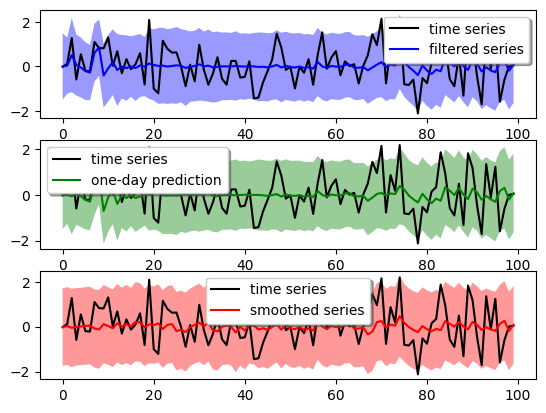

In [ ]:
from pydlm import dlm, dynamic
import numpy as np

# Main time series (y)
time_series = np.random.randn(100)

# Exogenous variable (X) - must be same length as y
exog = np.random.randn(100).reshape(-1, 1)  # 1D exogenous variable

# Build dynamic component for exog
exog_component = dynamic(features=exog, discount=0.99, name='exog', w=1.0)

# Define and fit model
model = dlm(time_series) + exog_component
model.fit()
model.plot()


INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...
INFO:pydlm:Forward filtering completed.
INFO:pydlm:Starting backward smoothing...
INFO:pydlm:Backward smoothing completed.


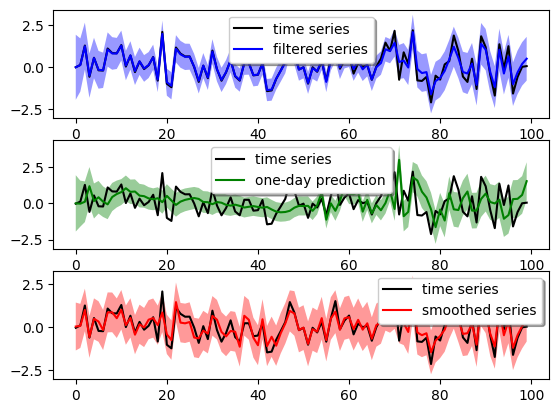

In [ ]:
from pydlm import dlm, trend, seasonality

# Define components
linear_trend = trend(degree=1, discount=0.95, name='linear_trend', w=10)
seasonal52 = seasonality(period=52, discount=0.99, name='seasonal52', w=10)

# Build and fit the model
simple_dlm = dlm(time_series) + linear_trend + seasonal52
simple_dlm.fit()

# Plot result
simple_dlm.plot()
